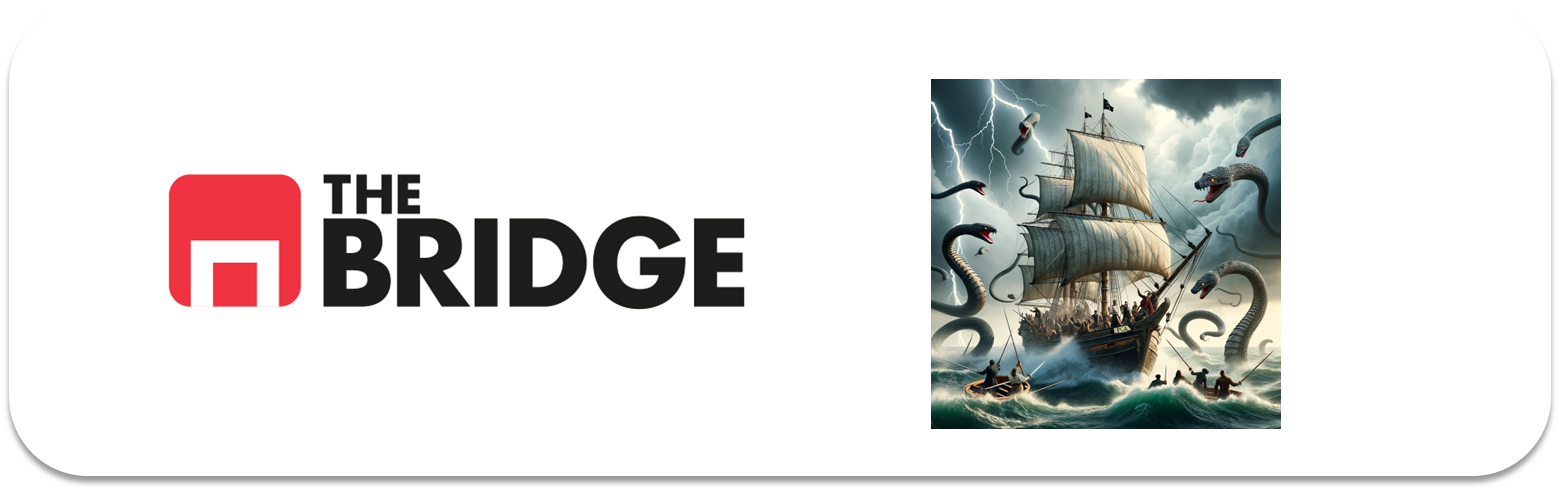

## PRACTICA OBLIGATORIA: **Seleccion Features**

* La práctica obligatoria de esta unidad consiste en hacer una comparativa de diferentes técnicas de selección de features sobre un dataset ya conocido. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Descripción General y Objetivo

El objetivo de la práctica es que juegues con las diferentes técncias de selección de features sobre un problema de clasificación. Para ello, tendrás que cargar el dataset de credit scoring que tienes en la carpeta "data" y que ya hemos trabajado anteriormente. A partir de ahí tendrás que probar diferentes técnicas de selección de features y compararlas todas entre sí y escoger finalmente el conjunto más sencillo con más potencia. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import bootcampviztools as bt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from collections import Counter
from lightgbm import LGBMClassifier
from scipy.stats import mannwhitneyu
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, SelectFromModel, RFE, SequentialFeatureSelector
from sklearn.metrics import mutual_info_score, classification_report
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from xgboost import XGBClassifier



### Detalles e Instrucciones

El objetivo es que construyas un modelo final de clasificació sobre la variable "SeriousDlqin2yrs" del dataset que encontrarás en "data".  

Sigue los pasos del proceso de ML que hemos aprendido para problemas supervisados con el dataset que encontrarás en "data" pero con las siguiente salvedades:

1. Deshazte de las filas con nulos, para este ejercicio no nos importan. Convierte las features NumberOf... que creas conveniente a categóricas con 2 o 3 niveles a lo sumo.

2. A la hora de hacer el miniEda aplica los siguientes análisis y selección de features: 
    1. Análisis visual combinado con filtrado por valores de correlación y umbral de covarianza.
    2. Selección de features numéricas mediante SelectKBest y ANOVA, selecció de features categóricas mediante Mutual Information 
    3. Selección de las mejores features a través de un modelo intermedio (usando SelectFromModel)
    4. Selección de las mejores features empleando RFE.
    5. Selección de las mejores features empleando SFS.
    6. Selección de las mejores features mediante un sistema de hard-voting aplicado a lo obtenido en los pasos 1 a 5 anteriores.

    Para cada paso anterior (salvo el 1) se pide obtener una lista de features de "primera división" con un número de variables no superior a 6 (pueden ser menos).

3. Escoge tres modelos y a la hora compararlos para escoger el mejor, entrenalos con validación cruzada empleando las seis listas obtenidas anteriormente. Es decir tendrás 18 (6*3) medidas (emplea la métrica que creas más conveniente y si no se te ocurre ninguna el recall medio).  Escoge el mejor modelo y la mejor selección de features.

4. Optimiza los hiperparámetros del mejor modelo. Evalúalo contra test.


In [2]:
df = pd.read_csv("./data/credit_npo.csv")
df

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.081892,37,0,0.070709,5656.0,12,1,0,0,0.0
1,0,0.023413,74,0,0.209197,4870.0,9,0,1,0,0.0
2,0,0.000000,43,0,0.080784,5000.0,2,0,0,0,2.0
3,0,0.492754,44,0,0.412735,7333.0,4,0,2,0,3.0
4,0,1.000000,63,0,0.000000,8333.0,3,0,0,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
12532,0,0.197116,59,0,0.290216,5140.0,6,0,1,0,0.0
12533,0,0.036726,62,0,0.884985,5833.0,12,0,1,0,0.0
12534,0,0.120313,49,0,0.577676,6333.0,7,0,2,0,2.0
12535,0,0.252566,63,0,0.037640,14000.0,9,0,0,0,1.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12537 entries, 0 to 12536
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      12537 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  12537 non-null  float64
 2   age                                   12537 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  12537 non-null  int64  
 4   DebtRatio                             12537 non-null  float64
 5   MonthlyIncome                         11816 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       12537 non-null  int64  
 7   NumberOfTimes90DaysLate               12537 non-null  int64  
 8   NumberRealEstateLoansOrLines          12537 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  12537 non-null  int64  
 10  NumberOfDependents                    12360 non-null  float64
dtypes: float64(4), 

1. Deshazte de las filas con nulos, para este ejercicio no nos importan. Convierte las features NumberOf... que creas conveniente a categóricas con 2 o 3 niveles a lo sumo.

In [4]:

df.dropna(inplace = True) 
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11816 entries, 0 to 12536
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      11816 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  11816 non-null  float64
 2   age                                   11816 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  11816 non-null  int64  
 4   DebtRatio                             11816 non-null  float64
 5   MonthlyIncome                         11816 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       11816 non-null  int64  
 7   NumberOfTimes90DaysLate               11816 non-null  int64  
 8   NumberRealEstateLoansOrLines          11816 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  11816 non-null  int64  
 10  NumberOfDependents                    11816 non-null  float64
dtypes: float64(4), int64

- Para crear las features primero habria que visualizarlas

In [5]:
target = "SeriousDlqin2yrs"

In [6]:
train_set, test_set = train_test_split(df, test_size = 0.2, random_state= 42)

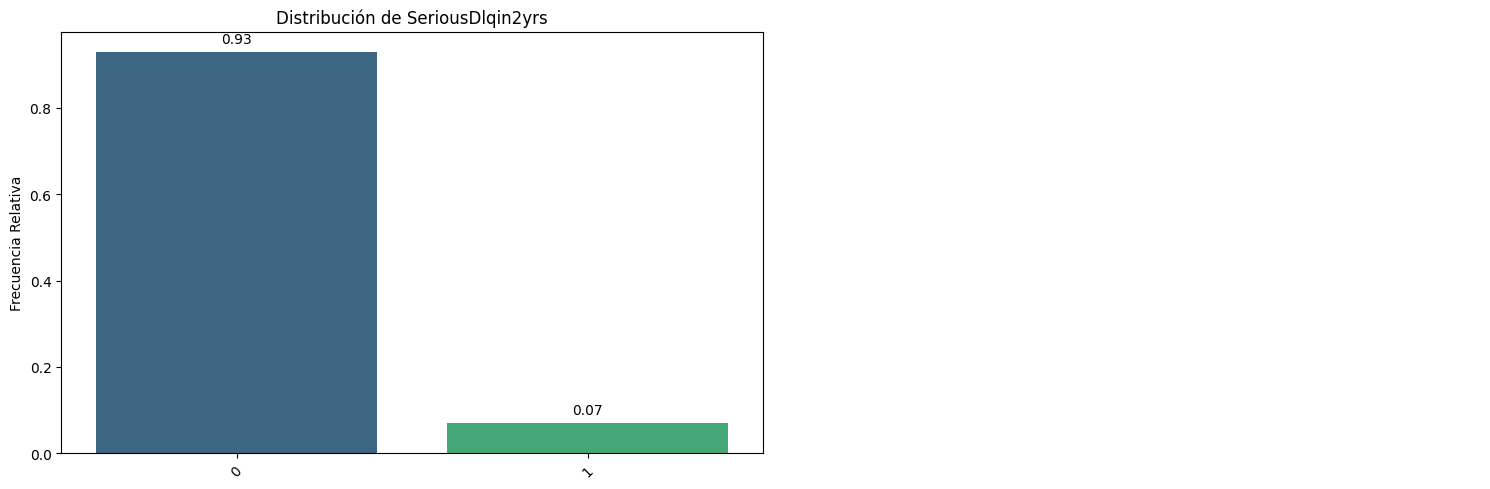

In [7]:
bt.pinta_distribucion_categoricas(train_set, [target], True, True)

- Vemos que esta desbalanceado nuestro target casi que de memoria, 93% de los registros pertenecen a la clase 0 y solo el 7% a la clase 1...

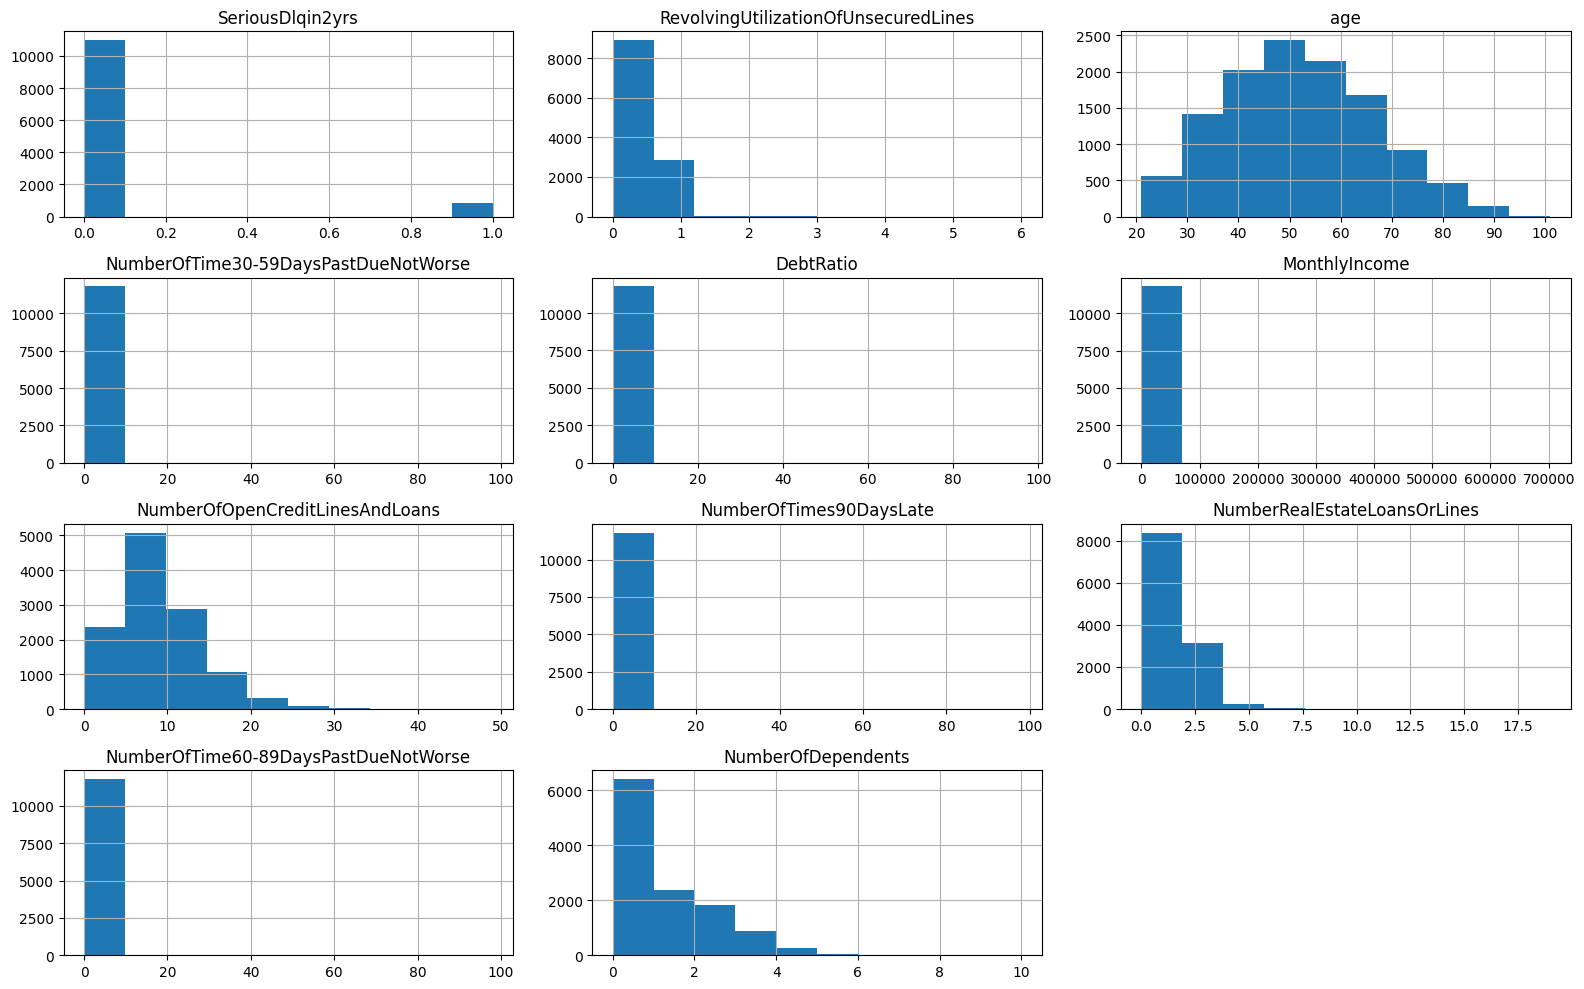

In [8]:
import matplotlib.pyplot as plt

df.hist(figsize=(16,10), bins=10)
plt.tight_layout()
plt.show()

Vemos que:
- ``NumberOfTime30-59DaysPastDueNotWorse``: muy concentrada en valor 0, la presencia de valores extremos puede indicar posibles outliers o anomalías, asi que encuentro razonable agruparla en pocas categorías.

- ``NumberOfTimes90DaysLate``: de igual modo que la anterior

- ``NumberOfTime60-89DaysPastDueNotWorse``: tambien conviene agruparla ya que esta igual muy concentrada en valor 0


In [9]:
# 1. Columnas que vamos a categorizar
cols_mora = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate',
    'NumberOfTime60-89DaysPastDueNotWorse'
]

# 2. Agrupar variables de mora en: 0, 1, 2+
for col in cols_mora:
    df[col] = pd.cut(
        df[col],
        bins=[-1, 0, 1, df[col].max()],
        labels=['0', '1', '2+']
    )


# 3. Revisar frecuencias
for col in cols_mora + ['NumberRealEstateLoansOrLines', 'NumberOfDependents']:
    print(df[col].value_counts())

NumberOfTime30-59DaysPastDueNotWorse
0     9818
1     1354
2+     644
Name: count, dtype: int64
NumberOfTimes90DaysLate
0     11156
1       394
2+      266
Name: count, dtype: int64
NumberOfTime60-89DaysPastDueNotWorse
0     11206
1       478
2+      132
Name: count, dtype: int64
NumberRealEstateLoansOrLines
0     4233
1     4149
2     2585
3      530
4      179
5       74
6       27
7       13
8        9
9        4
11       4
12       3
16       2
10       2
19       1
13       1
Name: count, dtype: int64
NumberOfDependents
0.0     6413
1.0     2369
2.0     1813
3.0      881
4.0      251
5.0       61
6.0       24
8.0        2
10.0       1
7.0        1
Name: count, dtype: int64


In [10]:
# Verifico
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11816 entries, 0 to 12536
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype   
---  ------                                --------------  -----   
 0   SeriousDlqin2yrs                      11816 non-null  int64   
 1   RevolvingUtilizationOfUnsecuredLines  11816 non-null  float64 
 2   age                                   11816 non-null  int64   
 3   NumberOfTime30-59DaysPastDueNotWorse  11816 non-null  category
 4   DebtRatio                             11816 non-null  float64 
 5   MonthlyIncome                         11816 non-null  float64 
 6   NumberOfOpenCreditLinesAndLoans       11816 non-null  int64   
 7   NumberOfTimes90DaysLate               11816 non-null  category
 8   NumberRealEstateLoansOrLines          11816 non-null  int64   
 9   NumberOfTime60-89DaysPastDueNotWorse  11816 non-null  category
 10  NumberOfDependents                    11816 non-null  float64 
dtypes: cate

In [11]:
features_num = ['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'DebtRatio',
 'MonthlyIncome',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfDependents',
 'NumberRealEstateLoansOrLines']

In [12]:
features_cat = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate',
    'NumberOfTime60-89DaysPastDueNotWorse'
]

In [13]:
features_num

['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'DebtRatio',
 'MonthlyIncome',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfDependents',
 'NumberRealEstateLoansOrLines']

In [14]:
features_cat

['NumberOfTime30-59DaysPastDueNotWorse',
 'NumberOfTimes90DaysLate',
 'NumberOfTime60-89DaysPastDueNotWorse']

2.1. Análisis visual combinado con filtrado por valores de correlación y umbral de covarianza.

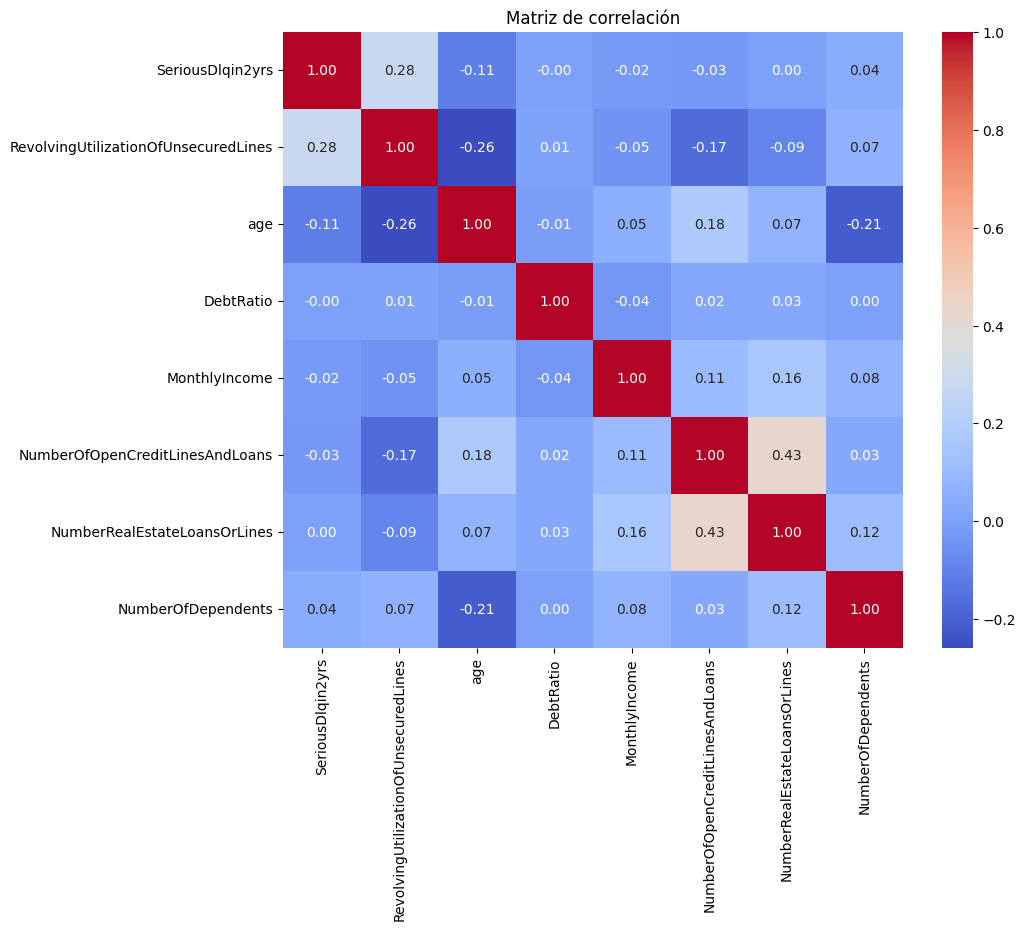

In [15]:
# 1. Seleccionar variables numéricas
df_num = df.select_dtypes(include=[np.number])

# 2. Matriz de correlación
corr = df_num.corr()

# 3. Filtro por umbral
umbral_corr = 0.3
corr_filtrada = corr[(corr.abs() >= umbral_corr)]

# 4. Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de correlación')
plt.show()

- Entre las variables, la relación más destacada se ve entre `NumberOfOpenCreditLinesAndLoans` y `NumberRealEstateLoansOrLines` (0.43), quienes tienen más líneas de crédito abiertas también tienden a tener más préstamos o líneas inmobiliarias. Luego en `age` vemos una correlación negativa con `RevolvingUtilizationOfUnsecuredLines` (-0.26) y con `NumberOfDependents` (-0.21), aunque en ambos casos la intensidad sigue siendo baja.
Por estar mas segura que features quedarme, analizare categoricas y numericas con el target: 

c:\Users\Usuario\Desktop\bootcamp-data1\Ds-Online-Daniela-Aguirre\04_Machine_Learning\Sprint_14\Unidad_02_ML_No_Supervisado_Feature_Selection\03_Practica_Obligatoria\bootcampviztools.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count_data = df.groupby([cat_col1, cat_col2]).size().reset_index(name='count')


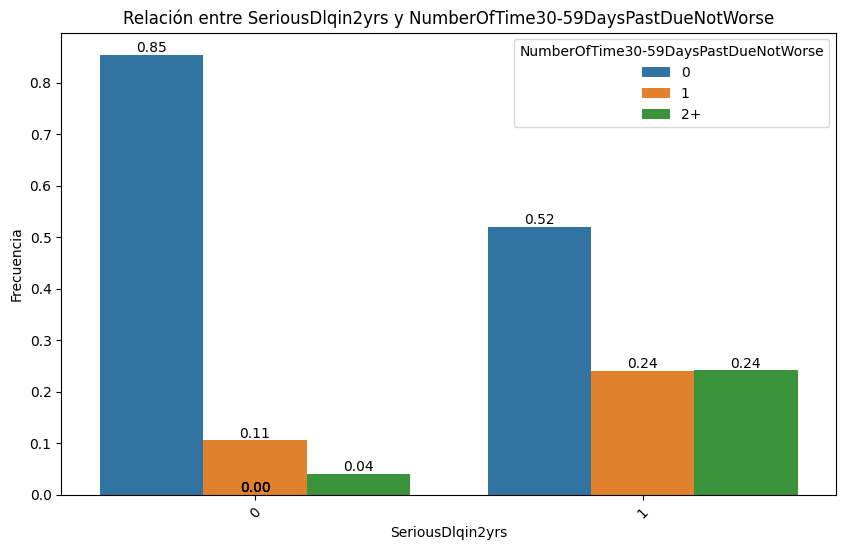

c:\Users\Usuario\Desktop\bootcamp-data1\Ds-Online-Daniela-Aguirre\04_Machine_Learning\Sprint_14\Unidad_02_ML_No_Supervisado_Feature_Selection\03_Practica_Obligatoria\bootcampviztools.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count_data = df.groupby([cat_col1, cat_col2]).size().reset_index(name='count')


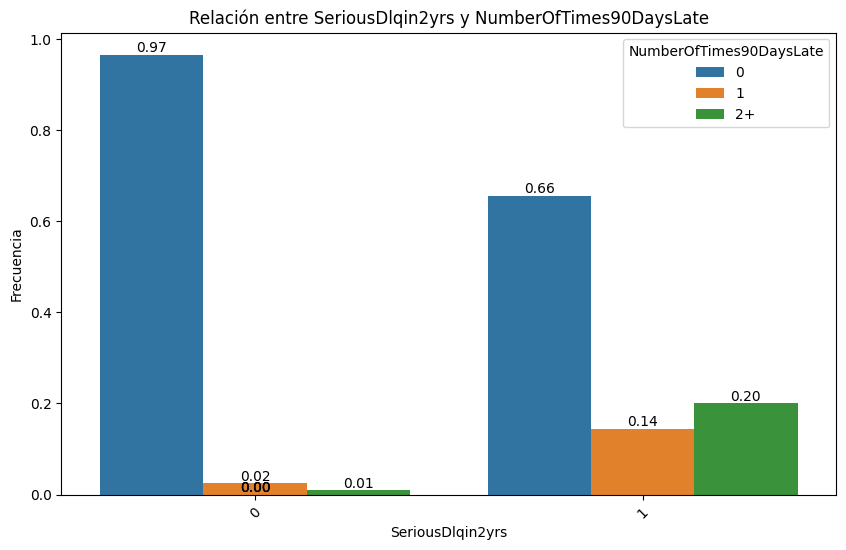

c:\Users\Usuario\Desktop\bootcamp-data1\Ds-Online-Daniela-Aguirre\04_Machine_Learning\Sprint_14\Unidad_02_ML_No_Supervisado_Feature_Selection\03_Practica_Obligatoria\bootcampviztools.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count_data = df.groupby([cat_col1, cat_col2]).size().reset_index(name='count')


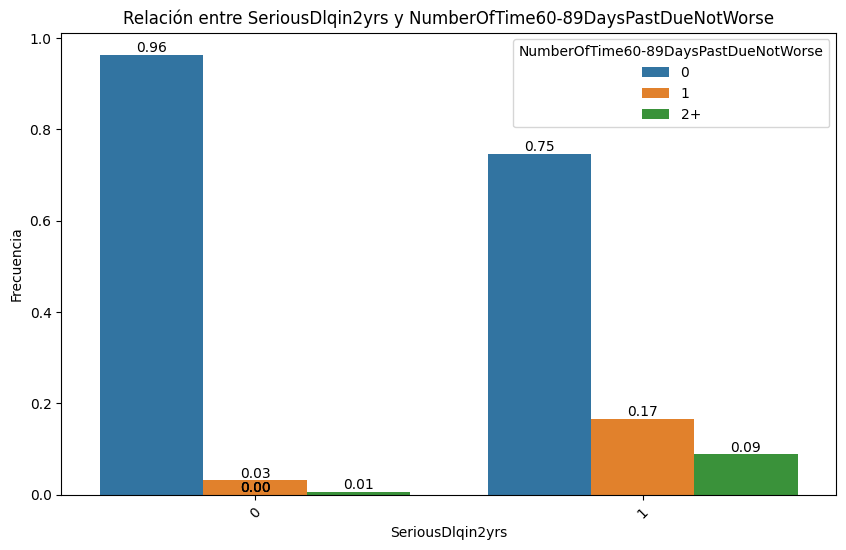

In [16]:
for col in features_cat:
    bt.plot_categorical_relationship_fin(df, target, col, True, True)

Con el análisis visual vemos una relación clara entre la variable objetivo `SeriousDlqin2yrs` y las variables asociadas a retrasos en pagos. En los tres casos, la clase 0 se concentra mayoritariamente en la categoría sin retrasos, mientras que la clase 1 tiene una mayor proporción de clientes con uno o más impagos. Esta diferencia se nota mas en `NumberOfTime30-59DaysPastDueNotWorse`, `NumberOfTimes90DaysLate` y `NumberOfTime60-89DaysPastDueNotWorse`, lo que sugiere que estas variables tienen capacidad discriminativa y podrían ser relevantes para predecir el riesgo de mora severa en los próximos dos años.

In [17]:
features_visual = features_cat.copy()

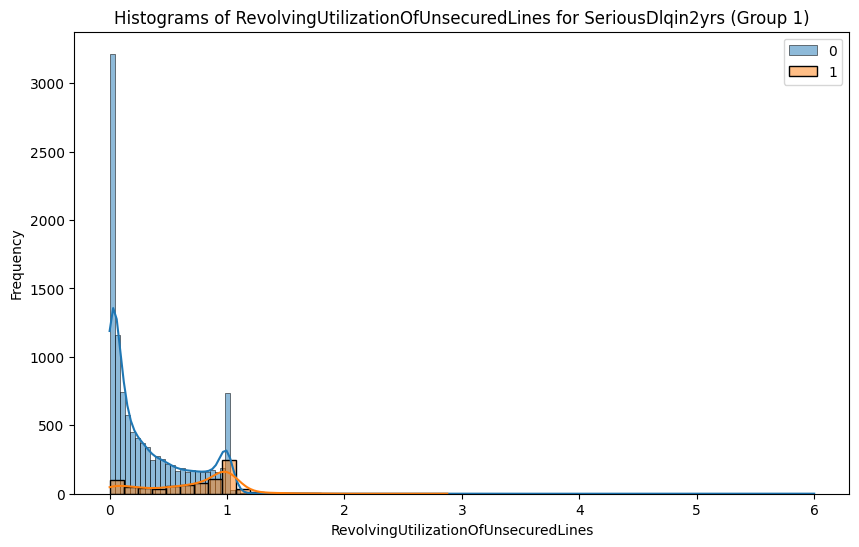

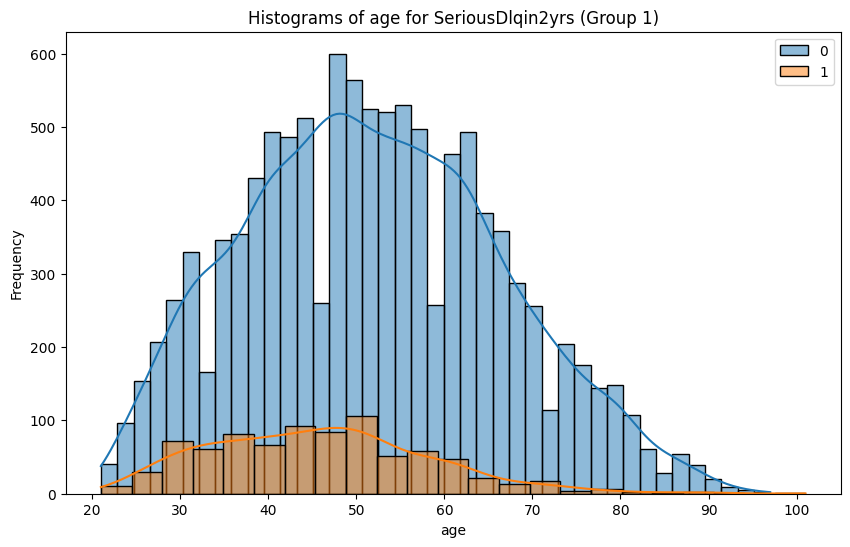

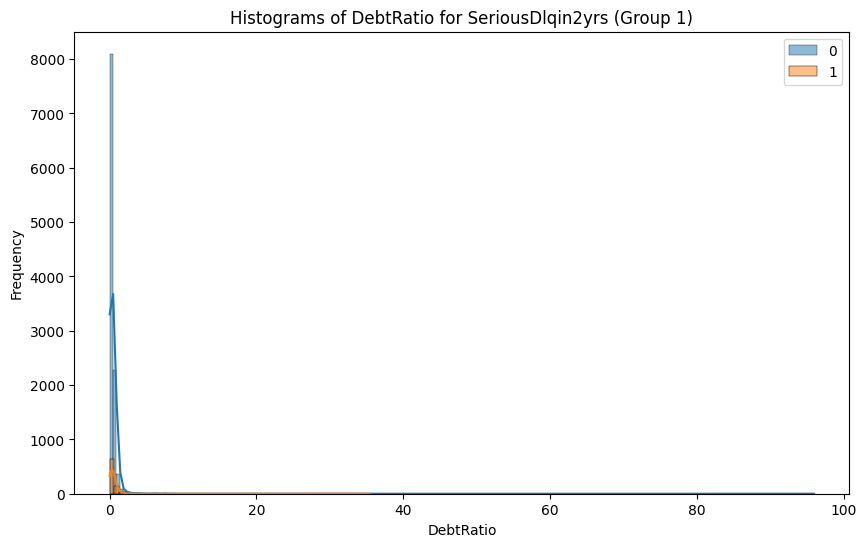

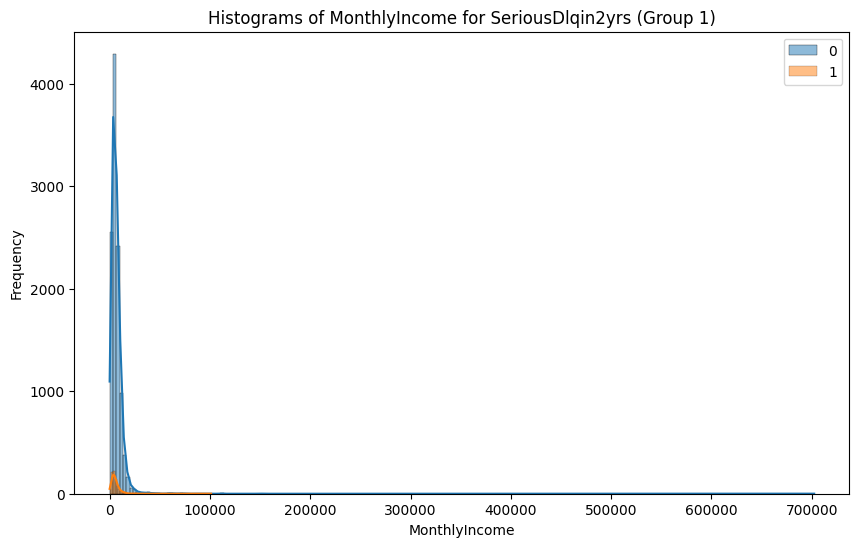

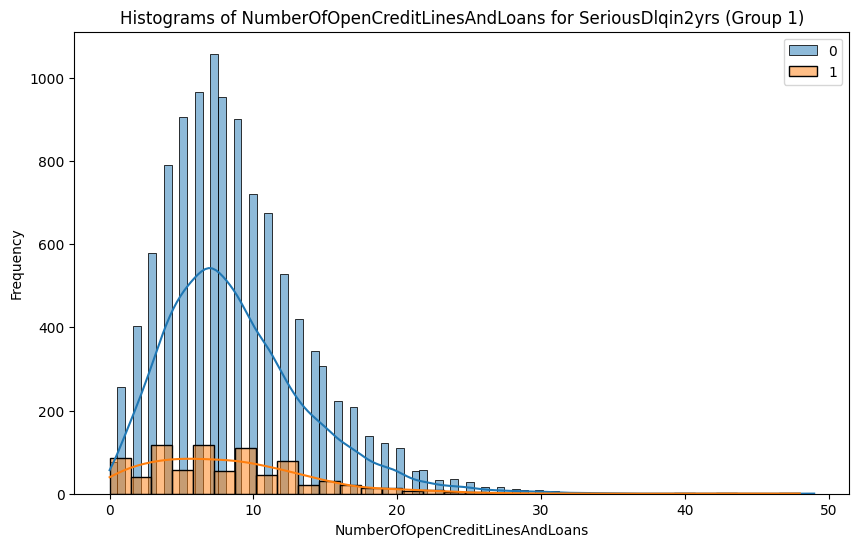

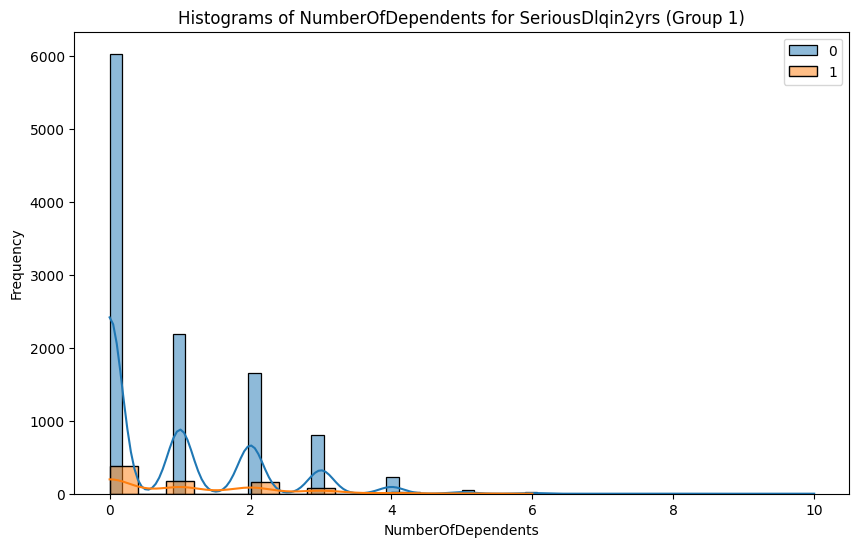

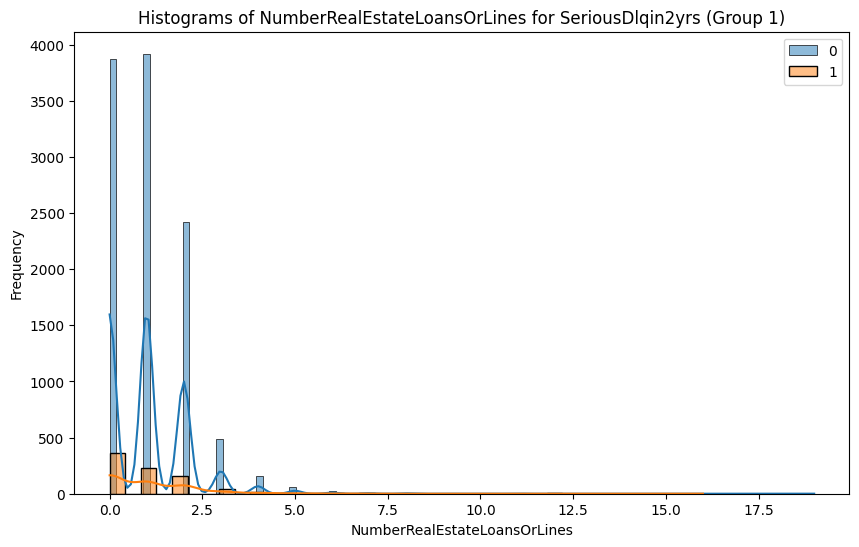

In [18]:
# Analizamos ahora las numericas
for col in features_num:
    bt.plot_grouped_histograms(df, cat_col= target, num_col= col, group_size= 2)

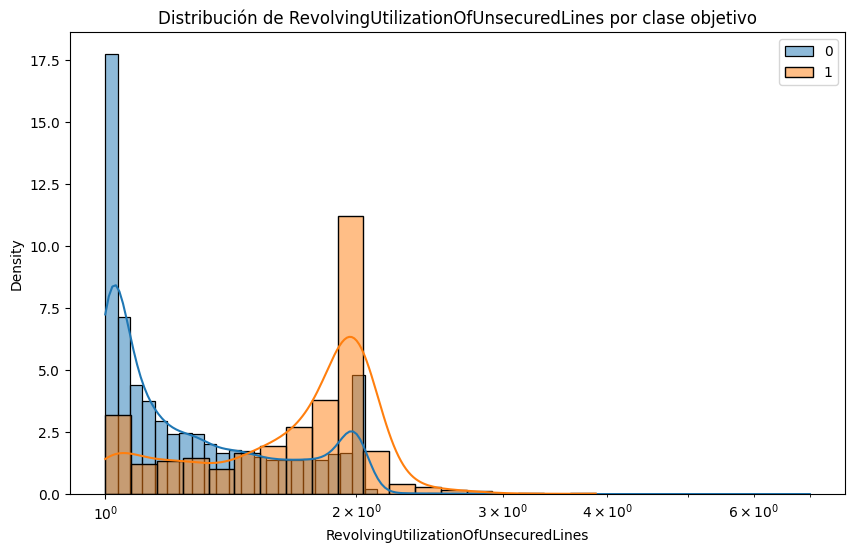

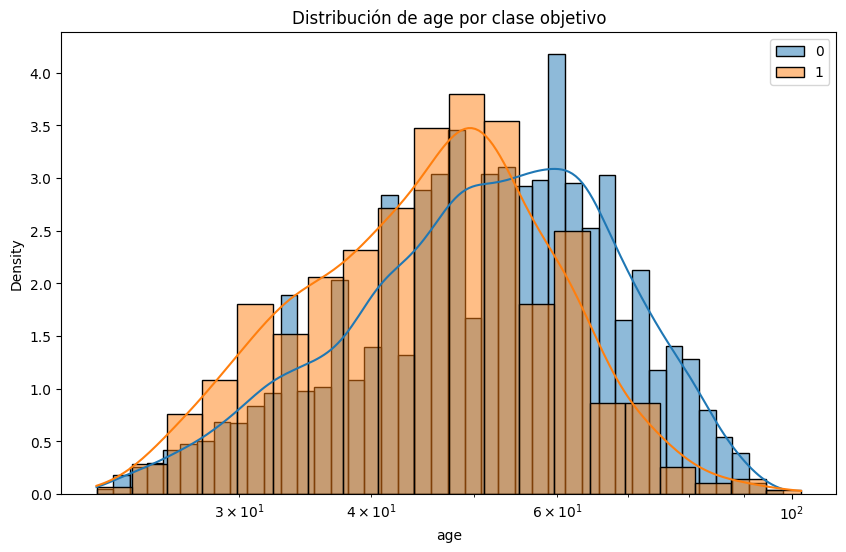

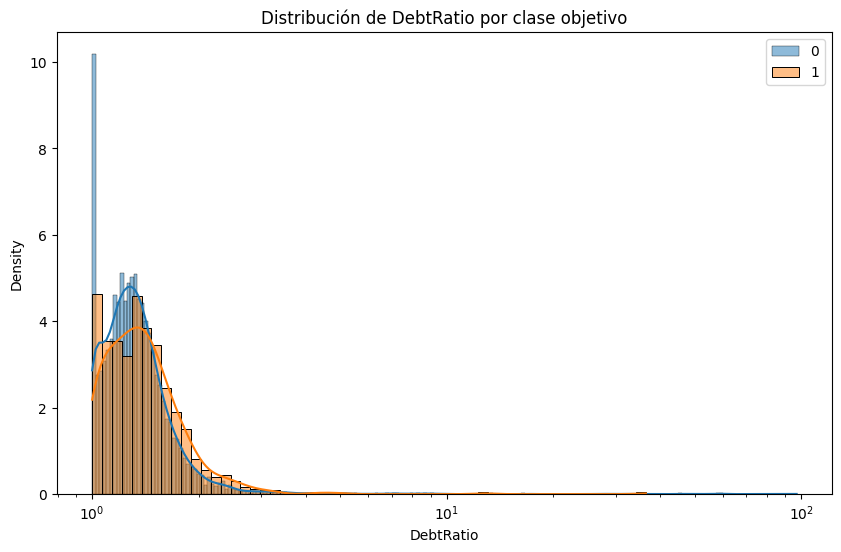

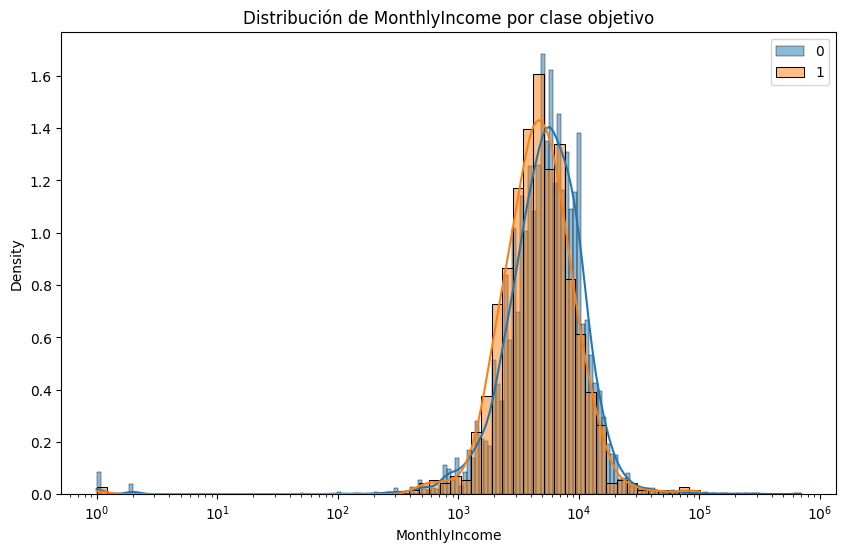

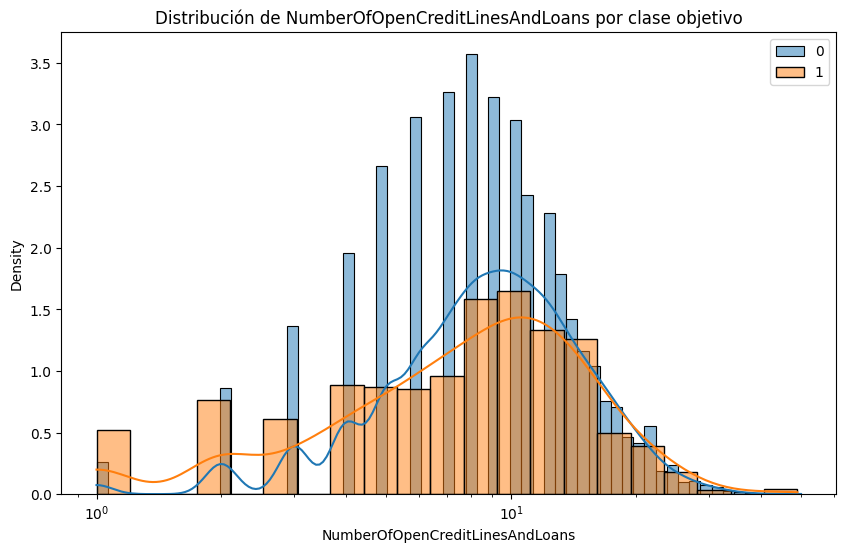

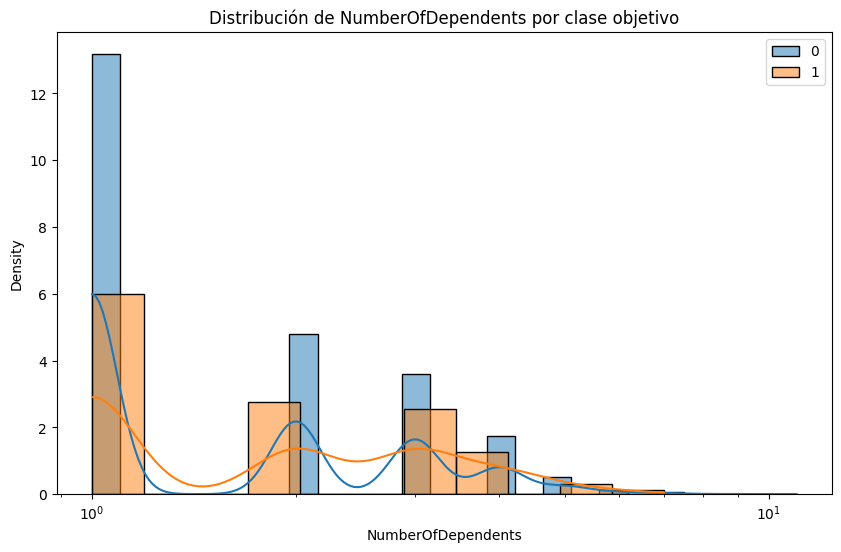

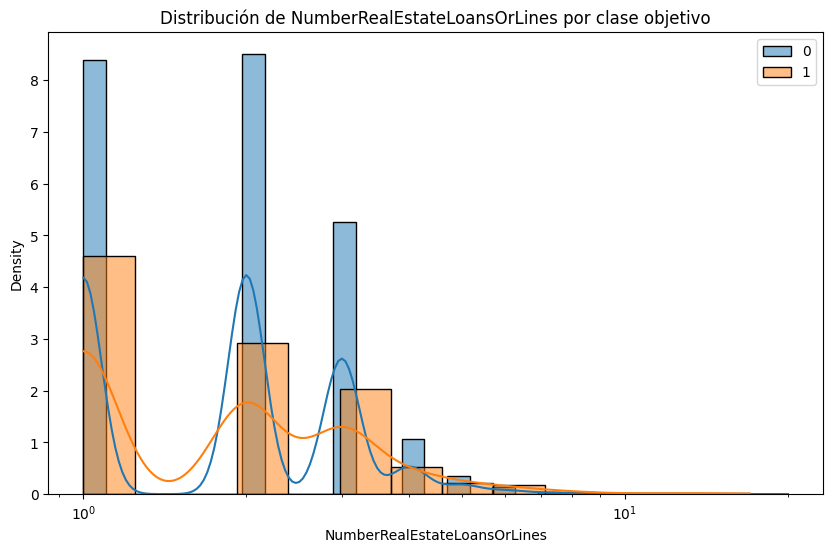

In [21]:
for col in features_num:
    plt.figure(figsize=(10,6))

    sns.histplot(
        x=df.loc[df[target] == 0, col] + 1,
        kde=True,
        stat="density",
        log_scale=True,
        label="0"
    )

    sns.histplot(
        x=df.loc[df[target] == 1, col] + 1,
        kde=True,
        stat="density",
        log_scale=True,
        label="1"
    )

    plt.title(f'Distribución de {col} por clase objetivo')
    plt.legend()
    plt.show()

- Visto ambas visualizaciones optaria por quedrame con todas ya que tienen informacion util para clasificar el target, la unica que me causa duda es ``DebtRatio`` se ve muy sesgada y con muchísimo solapamiento entre clases.
A simple vista no separa demasiado bien.

#### 2. Selección de features numéricas mediante SelectKBest y ANOVA, selecció de features categóricas mediante Mutual Information 


In [22]:
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif

# X e y
X = df.drop(columns=[target])
y = df[target]

# Separar columnas
features_num = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
features_cat = X.select_dtypes(include=['category', 'object']).columns.tolist()

print("Numéricas:", features_num)
print("Categóricas:", features_cat)

Numéricas: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberRealEstateLoansOrLines', 'NumberOfDependents']
Categóricas: ['NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTimes90DaysLate', 'NumberOfTime60-89DaysPastDueNotWorse']


In [ ]:
# SelectKBest para variables numéricas
selector_num = SelectKBest(score_func=f_classif, k='all') # uso k = 'all' primero para analizar cuáles son las más importantes antes de decidir cuántas quedarme ya que se puede usar por ejemplo k = 5
selector_num.fit(X[features_num], y)

scores_num = pd.DataFrame({
    'feature': features_num,
    'anova_score': selector_num.scores_,
    'p_value': selector_num.pvalues_
}).sort_values(by='anova_score', ascending=False)

scores_num

,feature,anova_score,p_value
0,RevolvingUtilizationOfUnsecuredLines,1007.740824,2.652100e-212
1,age,134.446536,6.413858e-31
6,NumberOfDependents,22.734336,1.882351e-06
4,NumberOfOpenCreditLinesAndLoans,10.341763,1.304037e-03
3,MonthlyIncome,5.824786,1.581701e-02
2,DebtRatio,0.032798,8.562901e-01
5,NumberRealEstateLoansOrLines,0.020601,8.858746e-01


- Aqui ya vemos que ``DebtRatio`` y *``NumberRealEstateLoansOrLines``* no nos aportan mucho... e incluso tambien descartaria *``MonthlyIncome``*

In [25]:
# Analizamos ahora categóricas
X_cat = X[features_cat].copy()

# Pasar categorías a códigos numéricos
for col in X_cat.columns:
    X_cat[col] = X_cat[col].astype('category').cat.codes

# Informacion mutua
mi_scores = mutual_info_classif(X_cat, y, discrete_features=True, random_state=42) # 'mutual_info_classif' mide cuánta información aporta cada feature para predecir la target

scores_cat = pd.DataFrame({
    'feature': features_cat,
    'mutual_info': mi_scores
}).sort_values(by='mutual_info', ascending=False)

scores_cat

,feature,mutual_info
1,NumberOfTimes90DaysLate,0.034896
0,NumberOfTime30-59DaysPastDueNotWorse,0.022988
2,NumberOfTime60-89DaysPastDueNotWorse,0.019647


- La selección de variables categóricas mediante Mutual Information nos indica que las tres variables relacionadas con retrasos en pagos aportan información relevante para predecir la variable objetivo. La más informativa es `NumberOfTimes90DaysLate`, seguida de `NumberOfTime30-59DaysPastDueNotWorse` y `NumberOfTime60-89DaysPastDueNotWorse`. Con esto refuerzamos la idea de que el historial de mora previa constituye un factor clave en la predicción del impago severo. Asì que sin mas me quedo con las 3

In [26]:
features_filter = ['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfDependents',
 'NumberOfTimes90DaysLate',
 'NumberOfTime30-59DaysPastDueNotWorse',
 'NumberOfTime60-89DaysPastDueNotWorse']

 #### 3. Selección de las mejores features a través de un modelo intermedio (usando SelectFromModel)

In [ ]:
# Ete codigo lo saque de chat ya que aun me quedan dudas de como emplearlo

from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

target = 'SeriousDlqin2yrs'

X = df.drop(columns=[target])
y = df[target]

X_model = X.copy()

for col in X_model.select_dtypes(include=['category', 'object']).columns:
    X_model[col] = X_model[col].astype('category').cat.codes

model = RandomForestClassifier(random_state=42, n_estimators=100)

selector = SelectFromModel(model, threshold='median') 
selector.fit(X_model, y)

selected_features = X_model.columns[selector.get_support()].tolist()

importances = pd.DataFrame({
    'feature': X_model.columns,
    'importance': selector.estimator_.feature_importances_
}).sort_values(by='importance', ascending=False)

print("Importancia de variables:")
print(importances)

print("\nFeatures seleccionadas:")
print(selected_features)

Importancia de variables:
                                feature  importance
0  RevolvingUtilizationOfUnsecuredLines    0.197518
3                             DebtRatio    0.158342
4                         MonthlyIncome    0.153341
1                                   age    0.118919
6               NumberOfTimes90DaysLate    0.103518
5       NumberOfOpenCreditLinesAndLoans    0.096615
9                    NumberOfDependents    0.046502
2  NumberOfTime30-59DaysPastDueNotWorse    0.043071
7          NumberRealEstateLoansOrLines    0.041319
8  NumberOfTime60-89DaysPastDueNotWorse    0.040855

Features seleccionadas:
['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'MonthlyIncome', 'NumberOfTimes90DaysLate']


- Vale, no me cuadra... pero coinciden algunas..

#### 4. Selección de las mejores features empleando RFE. Recursive Feature Elimination

In [ ]:
# Aplicamos como lo visto en las pildoras

from sklearn.feature_selection import RFE

rf_RFE = RandomForestClassifier(random_state= 42) 

rfe = RFE(estimator = rf_RFE,
          n_features_to_select= 6, # Iterará hasta quedarse con 6
          step = 1)

rfe.fit(train_set[features_filter], train_set[target])

,"estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance(e.g. `coef_`, `feature_importances_`).",RandomForestC...ndom_state=42)
,"n_features_to_select n_features_to_select: int or float, default=NoneThe number of features to select. If `None`, half of the features areselected. If integer, the parameter is the absolute number of featuresto select. If float between 0 and 1, it is the fraction of features toselect... versionchanged:: 0.24 Added float values for fractions.",6
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.",1
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance (implemented with `attrgetter`).For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case ofclass:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0


In [38]:
features_RFE = list(rfe.get_feature_names_out())
features_RFE

['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfDependents',
 'NumberOfTimes90DaysLate',
 'NumberOfTime30-59DaysPastDueNotWorse']

 ####  5. Selección de las mejores features empleando SFS.

In [43]:
target = "SeriousDlqin2yrs"

X_train = train_set.drop(columns=[target]).copy()
y_train = train_set[target]

for col in X_train.select_dtypes(include=['category', 'object']).columns:
    X_train[col] = X_train[col].astype('category').cat.codes

In [44]:
from sklearn.feature_selection import SequentialFeatureSelector

rf_SFS = RandomForestClassifier(random_state = 42)

sfs_forward = SequentialFeatureSelector(rf_SFS,
                                        n_features_to_select = 6,
                                        cv = 4,
                                        scoring = "balanced_accuracy")


sfs_forward.fit(X_train, y_train)

,estimator estimator: estimator instanceAn unfitted estimator.,RandomForestC...ndom_state=42)
,"n_features_to_select n_features_to_select: ""auto"", int or float, default=""auto""If `""auto""`, the behaviour depends on the `tol` parameter:- if `tol` is not `None`, then features are selected while the score change does not exceed `tol`.- otherwise, half of the features are selected.If integer, the parameter is the absolute number of features to select.If float between 0 and 1, it is the fraction of features to select... versionadded:: 1.1 The option `""auto""` was added in version 1.1... versionchanged:: 1.3 The default changed from `""warn""` to `""auto""` in 1.3.",6
,"tol tol: float, default=NoneIf the score is not incremented by at least `tol` between twoconsecutive feature additions or removals, stop adding or removing.`tol` can be negative when removing features using `direction=""backward""`.`tol` is required to be strictly positive when doing forward selection.It can be useful to reduce the number of features at the cost of a smalldecrease in the score.`tol` is enabled only when `n_features_to_select` is `""auto""`... versionadded:: 1.1",None
,"direction direction: {'forward', 'backward'}, default='forward'Whether to perform forward selection or backward selection.",'forward'
,"scoring scoring: str or callable, default=NoneScoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)`` that returns a single value. See :ref:`scoring_callable` for details.- `None`: the `estimator`'s :ref:`default evaluation criterion ` is used.",'balanced_accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. In all othercases, :class:`~sklearn.model_selection.KFold` is used. These splittersare instantiated with `shuffle=False` so the splits will be the sameacross calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.",4
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel. When evaluating a new feature toadd or remove, the cross-validation procedure is parallel over thefolds.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2


In [45]:
print("Elegidasd SFS:", sfs_forward.get_feature_names_out())

Elegidasd SFS: ['RevolvingUtilizationOfUnsecuredLines'
 'NumberOfTime30-59DaysPastDueNotWorse' 'NumberOfOpenCreditLinesAndLoans'
 'NumberOfTimes90DaysLate' 'NumberRealEstateLoansOrLines'
 'NumberOfTime60-89DaysPastDueNotWorse']


#### 6. Selección de las mejores features mediante un sistema de hard-voting aplicado a lo obtenido en los pasos 1 a 5 anteriores.


Para cada paso anterior (salvo el 1) se pide obtener una lista de features de "primera división" con un número de variables no superior a 6 (pueden ser menos).

3. Escoge tres modelos y a la hora compararlos para escoger el mejor, entrenalos con validación cruzada empleando las seis listas obtenidas anteriormente. Es decir tendrás 18 (6*3) medidas (emplea la métrica que creas más conveniente y si no se te ocurre ninguna el recall medio).  Escoge el mejor modelo y la mejor selección de features.

4. Optimiza los hiperparámetros del mejor modelo. Evalúalo contra test.

### EXTRA

Aplica la PCA como método de selección, escoge un número de componentes en función de la varianza explicada y crea un dataset con el que entrenar el mismo tipo de modelo ganador de la parte general. Entrenalo y evalúalo contra test, comenta el resultado.